# 05 · Variational Autoencoders (VAE) — From Compression to **Generation**

Every autoencoder so far has been about *understanding* existing data (compress, denoise, detect
anomalies, extract features). The **Variational Autoencoder** adds a superpower: it can **generate
brand-new data**. Sample a random point from its latent space, decode it, and out comes a *new*,
never-seen-but-plausible image.

This is the single richest autoencoder topic in an interview, because it forces you to connect
**probability, optimization, and deep learning** in one model.

**What you will learn here**

1. *Why a plain autoencoder can't generate:* its latent space has **holes**, so random points decode to garbage.
2. The VAE fix: the encoder outputs a **distribution** (μ, σ), and a **KL term** packs the whole
   latent space into a smooth standard normal you can sample from.
3. The **reparameterization trick** — how to backprop through randomness.
4. The **ELBO** loss = reconstruction + KL, explained term by term.
5. Build and train a VAE on Fashion-MNIST, then: **sample new images**, **interpolate** between items,
   and draw the famous **2-D latent manifold**.
6. A head-to-head: VAE vs plain AE sampling — and the honest limitations (blurriness, posterior collapse).

> Framework: **PyTorch**, CPU-only. Data: **Fashion-MNIST** (auto-downloaded once).


### 🟢 In plain language first (the 30-second version)

Before the math, here's the whole idea in one breath:

- A **normal autoencoder** takes an image and squeezes it into a **single fixed point** (a vector),
  then tries to rebuild it. The problem: that compressed space ends up **messy and full of holes**,
  so you can't reliably create anything new from it.
- A **VAE** does something smarter: instead of squeezing the input into a *point*, it squeezes it into
  a **probability distribution** — a little **Gaussian bell** (a mean `μ` and a spread `σ`). Forcing
  every input to become a well-behaved bell makes the whole latent space **continuous and tidy**.
- Because the space is tidy, you can **generate brand-new, realistic data** simply by *sampling* a
  random point from it and decoding — like drawing a random spot on a well-organized map and always
  landing somewhere meaningful.

> **Analogy:** a plain AE files each photo at one exact address; the streets *between* addresses are
> empty lots (holes). A VAE instead gives each photo a small *neighborhood*, and forces all
> neighborhoods to tile one city with no empty lots — so any random address you visit has a real
> building on it. The rest of this notebook just makes that precise.


## 1. Why a plain autoencoder cannot generate

A plain AE maps each input to a **single point** `z` and learns to decode *those specific points*. It
never learns what to do with the **empty space between and around** them. So if you pick a random
`z` and decode it, you likely land in a **hole** the decoder never saw → nonsense output.

```
   Plain AE latent space              VAE latent space
   (points + holes)                   (a smooth, packed distribution)

     z2 ▲   •      •                     z2 ▲   ░░▒▒▓▓▒▒░░
        │  •   ??? (hole)                   │  ░▒▒▓▓██▓▓▒▒░
        │     •   •     •                    │  ░▒▓▓████▓▓▒░
        │  •      ??? • •                     │  ░░▒▒▓▓▒▒░░
        └───────────────▶ z1                  └───────────────▶ z1
     decode a random z → garbage           decode a random z → a plausible new sample
```

Two things are wrong with the plain AE for generation: (1) we don't know **which distribution to
sample `z` from**, and (2) even if we guessed, there are **gaps** with no valid decoding. The VAE
fixes **both** by *forcing the latent codes to fill a known distribution* — the standard normal
$\mathcal{N}(0, I)$ — with **no holes**.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

torch.manual_seed(0); np.random.seed(0)

CLASSES = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
tr = torchvision.datasets.FashionMNIST("data", train=True,  download=True)
te = torchvision.datasets.FashionMNIST("data", train=False, download=True)
N_TRAIN, N_TEST = 15000, 3000
X_train = (tr.data[:N_TRAIN].float() / 255.0).reshape(-1, 784)
y_train = tr.targets[:N_TRAIN].numpy()
X_test  = (te.data[:N_TEST].float() / 255.0).reshape(-1, 784)
y_test  = te.targets[:N_TEST].numpy()
print("Fashion-MNIST:", tuple(X_train.shape), "| device: CPU")


Fashion-MNIST: (15000, 784) | device: CPU


## 2. The VAE idea: encode a *distribution*, not a point

Instead of mapping `x` to one code, the VAE's encoder outputs the **parameters of a Gaussian**: a
mean vector `μ(x)` and a (log-)variance `log σ²(x)`. The code `z` is then a **sample** from that little
Gaussian. Intuitively, each input claims a *fuzzy blob* of latent space rather than a single dot — and
the blobs, packed together, tile the space with **no gaps**.

```
                          ┌───────── ENCODER ─────────┐
                          │                    ┌─▶ μ(x)   (mean)
        x ───────────────▶│   neural net       │
     (784 pixels)         │                    └─▶ logσ²(x) (spread)
                          └───────────────────────────┘
                                       │
                        z = μ + σ·ε ,   ε ~ N(0, I)     ← reparameterization (sample)
                                       │
                          ┌───────── DECODER ─────────┐
                          │  neural net  ─────────────┼──▶ x̂  (reconstruction / a sample)
                          └───────────────────────────┘

   Loss = reconstruct x well   +   keep each blob close to N(0, I)  (the KL term)
```

The magic is the **KL term**: it pulls every input's Gaussian toward the *same* standard normal
$\mathcal{N}(0, I)$. After training, the aggregate of all codes ≈ $\mathcal{N}(0, I)$ — so to
generate, we simply **sample $z \sim \mathcal{N}(0, I)$ and decode**. No holes, known distribution.


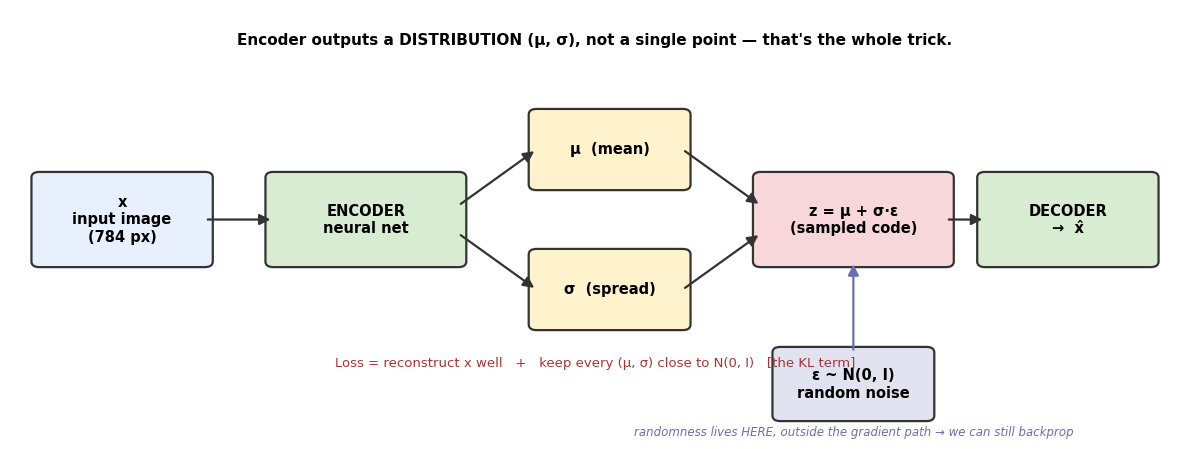

In [2]:
# 📊 A picture of the whole VAE (run me) — the same flow as the ASCII sketch above, drawn cleanly.
# Read it left to right: an image goes in, the encoder turns it into a Gaussian (μ, σ), we SAMPLE a
# point z from that Gaussian using the reparameterization trick, and the decoder rebuilds an image.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.set_xlim(0, 12); ax.set_ylim(0, 6); ax.axis("off")

def box(x, y, w, h, text, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                                linewidth=1.6, edgecolor="#333", facecolor=color))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10.5, weight="bold")

def arrow(x1, y1, x2, y2, text="", color="#333"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                 mutation_scale=16, linewidth=1.6, color=color))
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.28, text, ha="center", va="bottom", fontsize=9, color=color)

# main pipeline
box(0.3, 2.4, 1.7, 1.2, "x\ninput image\n(784 px)", "#e8f0fe")
box(2.7, 2.4, 1.9, 1.2, "ENCODER\nneural net", "#d7ecd0")
box(5.4, 3.5, 1.5, 1.0, "μ  (mean)", "#fff3cd")
box(5.4, 1.5, 1.5, 1.0, "σ  (spread)", "#fff3cd")
box(7.7, 2.4, 1.9, 1.2, "z = μ + σ·ε\n(sampled code)", "#f8d7da")
box(10.0, 2.4, 1.7, 1.2, "DECODER\n→  x̂", "#d7ecd0")

# noise input for the reparameterization trick
box(7.9, 0.2, 1.5, 0.9, "ε ~ N(0, I)\nrandom noise", "#e2e3f0")

arrow(2.0, 3.0, 2.7, 3.0)
arrow(4.6, 3.2, 5.4, 4.0)           # encoder -> mu
arrow(4.6, 2.8, 5.4, 2.0)           # encoder -> sigma
arrow(6.9, 4.0, 7.7, 3.2)           # mu -> z
arrow(6.9, 2.0, 7.7, 2.8)           # sigma -> z
arrow(8.65, 1.1, 8.65, 2.4, color="#6a6fb0")   # noise -> z (the trick)
arrow(9.6, 3.0, 10.0, 3.0)          # z -> decoder

ax.text(8.65, 0.05, "randomness lives HERE, outside the gradient path → we can still backprop",
        ha="center", va="top", fontsize=8.5, style="italic", color="#6a6fb0")
ax.text(6.0, 5.5, "Encoder outputs a DISTRIBUTION (μ, σ), not a single point — that's the whole trick.",
        ha="center", fontsize=11, weight="bold")
ax.text(6.0, 0.9, "Loss = reconstruct x well   +   keep every (μ, σ) close to N(0, I)   [the KL term]",
        ha="center", fontsize=9.5, color="#a33")
plt.tight_layout(); plt.show()


### The reparameterization trick — backprop through randomness

There's a snag: `z` is a **random sample**, and you can't backpropagate through "draw a random
number". The trick is to move the randomness **outside** the gradient path:

$$ z = \mu(x) + \sigma(x)\,\odot\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I) $$

Now `ε` is a constant noise input (no gradient needed), while `μ` and `σ` are **deterministic**
network outputs the gradient *can* flow through. Same random `z`, but now trainable.

```
   WITHOUT trick (blocked):   x ─▶ μ,σ ─▶ [ sample z ] ─▶ decode      ✗ can't grad through sampling
   WITH trick (works):        x ─▶ μ,σ ──┐
                                ε ~ N(0,I)─┴▶ z = μ + σ·ε ─▶ decode    ✓ grad flows through μ,σ
```


### The loss: the ELBO (Evidence Lower BOund)

A VAE maximizes a lower bound on the data likelihood. In plain terms the loss (to **minimize**) has
exactly two terms:

$$ \mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}\big[\,-\log p(x\mid z)\,\big]}_{\textbf{reconstruction}} \;+\; \underbrace{D_{\mathrm{KL}}\!\big(q(z\mid x)\,\Vert\,\mathcal{N}(0,I)\big)}_{\textbf{regularizer (KL)}} $$

- **Reconstruction term** — decode `z` back to `x` accurately (here: binary cross-entropy per pixel).
- **KL term** — keep each input's Gaussian `q(z|x)=N(μ,σ²)` close to the prior `N(0,I)`. For two
  Gaussians this has a clean closed form:

$$ D_{\mathrm{KL}} = -\tfrac{1}{2}\sum_{j}\big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\big) $$

The two terms **pull against each other**: reconstruction wants to spread codes far apart (easy to
tell inputs apart); KL wants to pull them all to the origin (smooth, sampleable). The balance is what
produces a **continuous, gap-free** latent space.


In [ ]:
class VAE(nn.Module):
    def __init__(self, d=784, h=256, latent=16):
        super().__init__()
        self.fc1 = nn.Linear(d, h)                 # shared encoder body
        self.fc_mu     = nn.Linear(h, latent)      # μ: the MEAN of the latent Gaussian (its center)
        self.fc_logvar = nn.Linear(h, latent)      # log(σ²): the LOG-variance. We predict the log so that
                                                   #   σ² = exp(logσ²) is always > 0, no matter what the net outputs
        self.decoder = nn.Sequential(
            nn.Linear(latent, h), nn.ReLU(),
            nn.Linear(h, d), nn.Sigmoid())         # Sigmoid -> pixels back in [0,1] (matches our normalized input)

    def encode(self, x):
        # Instead of one point, the encoder returns a whole distribution: a center (μ) and a spread (logσ²)
        hh = F.relu(self.fc1(x))
        return self.fc_mu(hh), self.fc_logvar(hh)

    def reparameterize(self, mu, logvar):
        # We need a sample z from N(μ, σ²). But "just draw a random number" is a dead end: sampling is random,
        # so gradients can't flow back through it and the encoder would never learn μ and σ.
        # The reparameterization trick rewrites the sample as a DETERMINISTIC function of μ, σ and a fixed
        # noise ε ~ N(0,1):   z = μ + σ·ε.  Any point of a Gaussian can be written this way, and now the
        # randomness (ε) sits OUTSIDE the gradient path, so we can backprop through μ and σ normally.
        std = torch.exp(0.5 * logvar)              # σ = exp(½·logσ²)   because logvar = log(σ²) → σ = exp(0.5·logσ²)
        eps = torch.randn_like(std)                # ε ~ N(0, I)  (the external, non-trainable randomness)
        return mu + eps * std                      # z = μ + σ·ε

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss(recon, x, mu, logvar):
    """ELBO = reconstruction (BCE) + KL, summed per-sample then averaged over the batch."""
    # 1) RECONSTRUCTION: how close is the rebuilt image to the original? BCE works well for pixels in [0,1]
    #    (MSE also works). This term alone would just make a good autoencoder — but with holes in the latent.
    bce = F.binary_cross_entropy(recon, x, reduction="sum") / x.size(0)
    # 2) KL: pushes each input's Gaussian N(μ, σ²) to look like the standard normal N(0,1). This is what
    #    makes the latent space continuous and structured, so we can sample z ~ N(0,1) to GENERATE new
    #    images and interpolate smoothly between items. Without it, the model could scatter each class to
    #    its own isolated spot, leaving gaps everywhere and making generation impossible.
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    # The two terms pull against each other: reconstruction wants codes spread far apart (easy to tell
    # inputs apart); KL wants them packed at the origin (smooth & sampleable). Their balance = the VAE.
    return bce + kld, bce, kld

vae = VAE(latent=16)
print(vae)
print("parameters:", f"{sum(p.numel() for p in vae.parameters()):,}")


## 3. Train the VAE

We track both loss components. Watch the **reconstruction** term fall (images get sharper) while the
**KL** term settles to a modest value (the latent stays close to `N(0, I)`, keeping it sampleable).


epoch  6 | ELBO  257.62 | recon  242.59 | KL  15.03


epoch 12 | ELBO  249.60 | recon  234.48 | KL  15.12


epoch 18 | ELBO  246.28 | recon  230.99 | KL  15.29


epoch 24 | ELBO  244.49 | recon  229.00 | KL  15.49


epoch 30 | ELBO  243.39 | recon  227.78 | KL  15.61


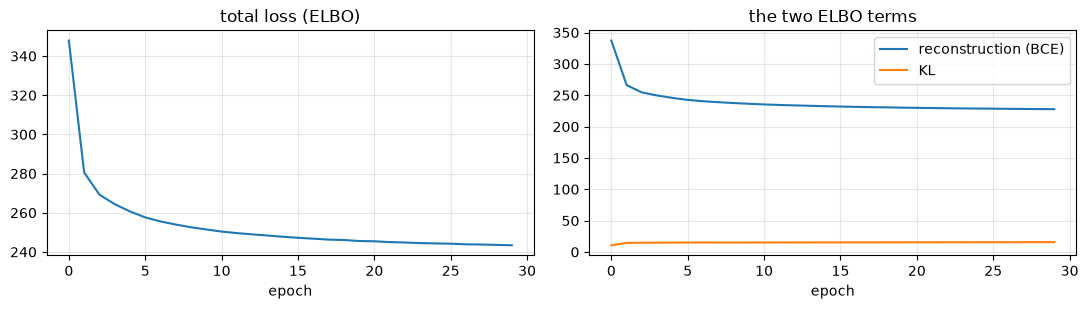

In [3]:
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS, BATCH = 30, 128
n = len(X_train); hist = []
for epoch in range(EPOCHS):
    vae.train(); perm = torch.randperm(n); tot = tot_b = tot_k = 0.0
    for i in range(0, n, BATCH):
        xb = X_train[perm[i:i+BATCH]]
        recon, mu, logvar = vae(xb)
        loss, bce, kld = vae_loss(recon, xb, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item()*len(xb); tot_b += bce.item()*len(xb); tot_k += kld.item()*len(xb)
    hist.append((tot/n, tot_b/n, tot_k/n))
    if (epoch+1) % 6 == 0:
        print(f"epoch {epoch+1:2d} | ELBO {tot/n:7.2f} | recon {tot_b/n:7.2f} | KL {tot_k/n:6.2f}")

h = np.array(hist)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(h[:,0]); ax[0].set_title("total loss (ELBO)"); ax[0].set_xlabel("epoch"); ax[0].grid(alpha=0.3)
ax[1].plot(h[:,1], label="reconstruction (BCE)"); ax[1].plot(h[:,2], label="KL")
ax[1].set_title("the two ELBO terms"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### First check: reconstructions still work

A VAE is still an autoencoder — it should reconstruct inputs. (They'll be a touch **blurrier** than a
plain AE: the KL term and the sampling noise trade a little sharpness for a smooth latent space — a
known, characteristic VAE tradeoff.)


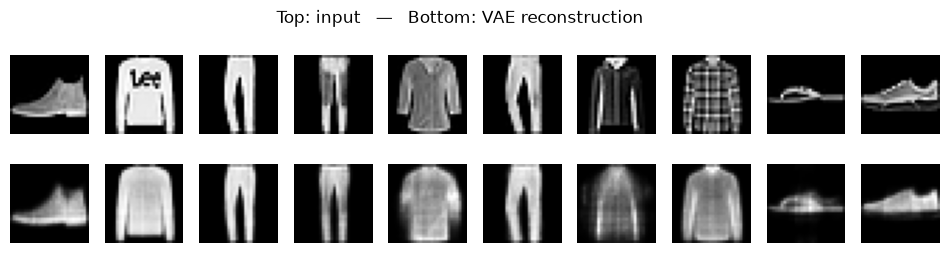

In [4]:
vae.eval()
with torch.no_grad():
    recon, _, _ = vae(X_test[:10])
fig, axes = plt.subplots(2, 10, figsize=(12, 2.6))
for j in range(10):
    axes[0, j].imshow(X_test[j].reshape(28,28), cmap="gray"); axes[0, j].axis("off")
    axes[1, j].imshow(recon[j].reshape(28,28),  cmap="gray"); axes[1, j].axis("off")
fig.text(0.5, 0.98, "Top: input   —   Bottom: VAE reconstruction", ha="center", fontsize=12)
plt.show()


## 4. The payoff #1 — **generate new images** from noise

This is what a plain AE cannot do. We **sample `z ~ N(0, I)`** — pure random noise in latent space —
and decode. Because the KL term packed all real codes into that same `N(0, I)`, every random draw
lands on a *valid* region and decodes to a **new, plausible clothing item** that exists in no dataset.


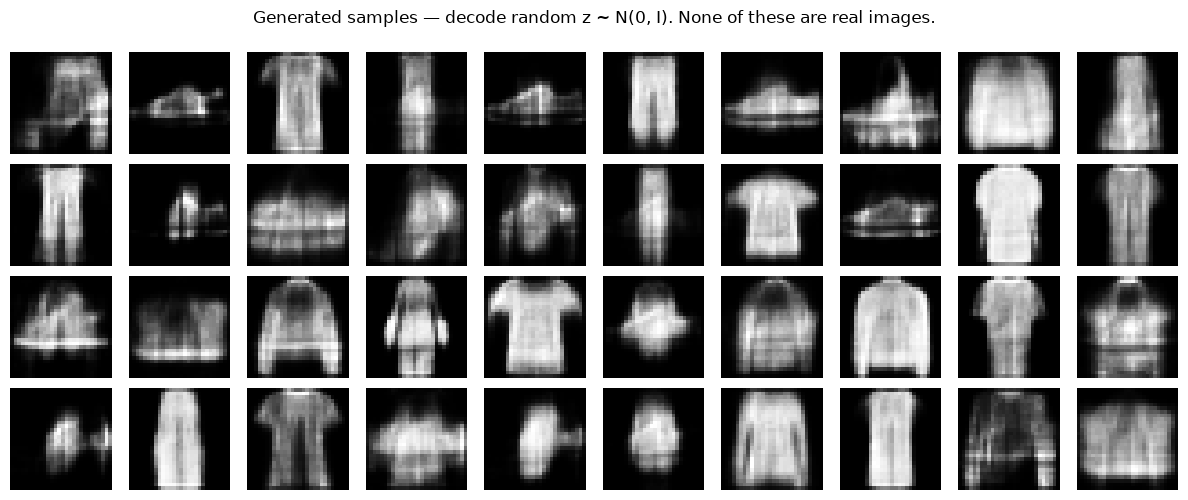

In [5]:
vae.eval()
with torch.no_grad():
    z_samples = torch.randn(40, 16)            # 40 random points in latent space
    generated = vae.decoder(z_samples)

fig, axes = plt.subplots(4, 10, figsize=(12, 5))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(generated[k].reshape(28,28), cmap="gray"); ax.axis("off")
fig.suptitle("Generated samples — decode random z ~ N(0, I). None of these are real images.", y=0.99)
plt.tight_layout(); plt.show()


## 5. The payoff #2 — **interpolate** in latent space

A smooth latent space means we can **walk a straight line from one item's code to another's** and
decode the points along the way, producing a **morph**. A plain AE's holes would make this jump
abruptly; the VAE morphs continuously — evidence the space is genuinely gap-free.


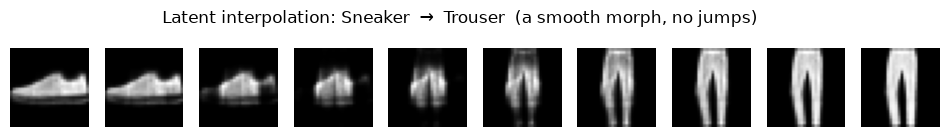

In [6]:
vae.eval()
# pick two visually different items, e.g. a sneaker (7) and a trouser (1)
i_a = np.where(y_test == 7)[0][0]
i_b = np.where(y_test == 1)[0][0]
with torch.no_grad():
    mu_a, _ = vae.encode(X_test[i_a:i_a+1])
    mu_b, _ = vae.encode(X_test[i_b:i_b+1])
    alphas = np.linspace(0, 1, 10)
    interp = torch.cat([vae.decoder((1-a)*mu_a + a*mu_b) for a in alphas])

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for j, ax in enumerate(axes):
    ax.imshow(interp[j].reshape(28,28), cmap="gray"); ax.axis("off")
fig.suptitle(f"Latent interpolation: {CLASSES[7]}  →  {CLASSES[1]}  (a smooth morph, no jumps)")
plt.show()


## 6. The payoff #3 — the famous **2-D latent manifold**

To *see* the whole latent space, we train a second VAE with a **2-D** latent. Then we can (a) plot the
code of every test image on the plane, colored by class, and (b) sweep a grid over the plane, decode
each point, and tile the results into the iconic **manifold map** where categories blend into their
neighbours.


In [7]:
torch.manual_seed(1)
vae2 = VAE(latent=2)
opt2 = torch.optim.Adam(vae2.parameters(), lr=1e-3)
for epoch in range(30):
    perm = torch.randperm(n)
    for i in range(0, n, BATCH):
        xb = X_train[perm[i:i+BATCH]]
        recon, mu, logvar = vae2(xb)
        loss, _, _ = vae_loss(recon, xb, mu, logvar)
        opt2.zero_grad(); loss.backward(); opt2.step()
vae2.eval()
with torch.no_grad():
    mu_all, _ = vae2.encode(X_test)
mu_all = mu_all.numpy()
print("trained a 2-D-latent VAE for visualization.")


trained a 2-D-latent VAE for visualization.


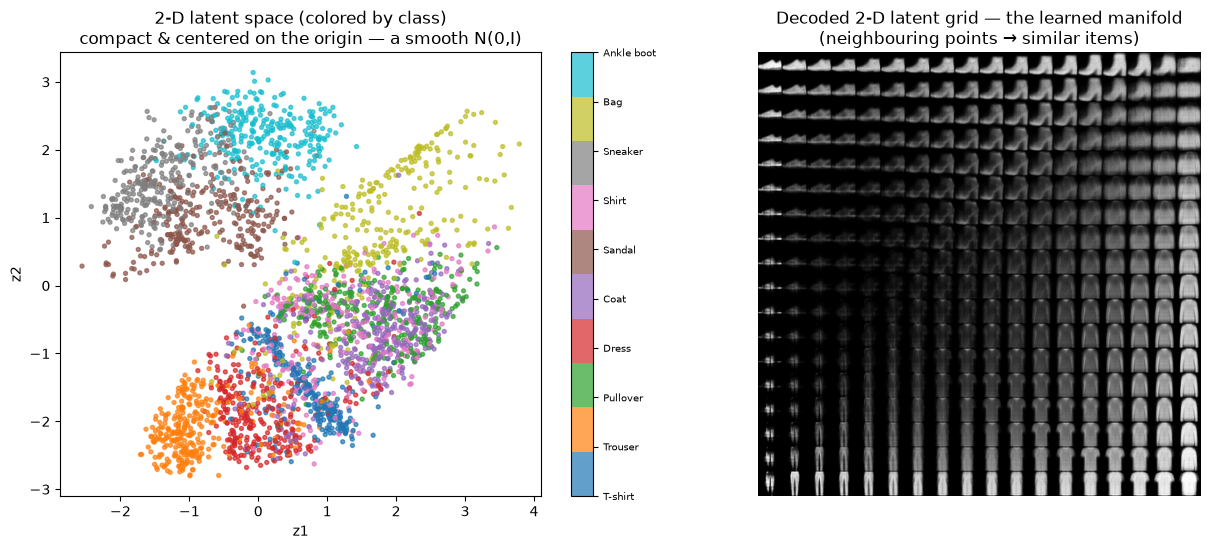

In [8]:
from scipy.stats import norm

fig, ax = plt.subplots(1, 2, figsize=(13, 5.6))

# (a) latent scatter, colored by true class
sc = ax[0].scatter(mu_all[:,0], mu_all[:,1], c=y_test, cmap="tab10", s=8, alpha=0.7)
ax[0].set_title("2-D latent space (colored by class)\ncompact & centered on the origin — a smooth N(0,I)")
ax[0].set_xlabel("z1"); ax[0].set_ylabel("z2")
cb = plt.colorbar(sc, ax=ax[0], ticks=range(10)); cb.ax.set_yticklabels(CLASSES, fontsize=7)

# (b) decode a grid placed at standard-normal quantiles -> the manifold
G = 18
grid = norm.ppf(np.linspace(0.02, 0.98, G))          # quantiles of N(0,1)
canvas = np.zeros((28*G, 28*G))
with torch.no_grad():
    for r, zy in enumerate(grid):
        for c, zx in enumerate(grid):
            img = vae2.decoder(torch.tensor([[zx, zy]], dtype=torch.float32)).reshape(28,28).numpy()
            canvas[(G-1-r)*28:(G-r)*28, c*28:(c+1)*28] = img
ax[1].imshow(canvas, cmap="gray"); ax[1].axis("off")
ax[1].set_title("Decoded 2-D latent grid — the learned manifold\n(neighbouring points → similar items)")
plt.tight_layout(); plt.show()


## 7. VAE vs plain AE — the sampling test, side by side

The cleanest way to *prove* the KL term matters: train a **plain AE** with the same architecture and
try to generate from it. We sample its latent from a Gaussian **fitted to its own training codes** (a
fair attempt to sample it) and decode. The plain AE's samples are **muddier and less coherent** —
because its latent has holes and no enforced shape. Same test for the VAE (`z ~ N(0, I)`).


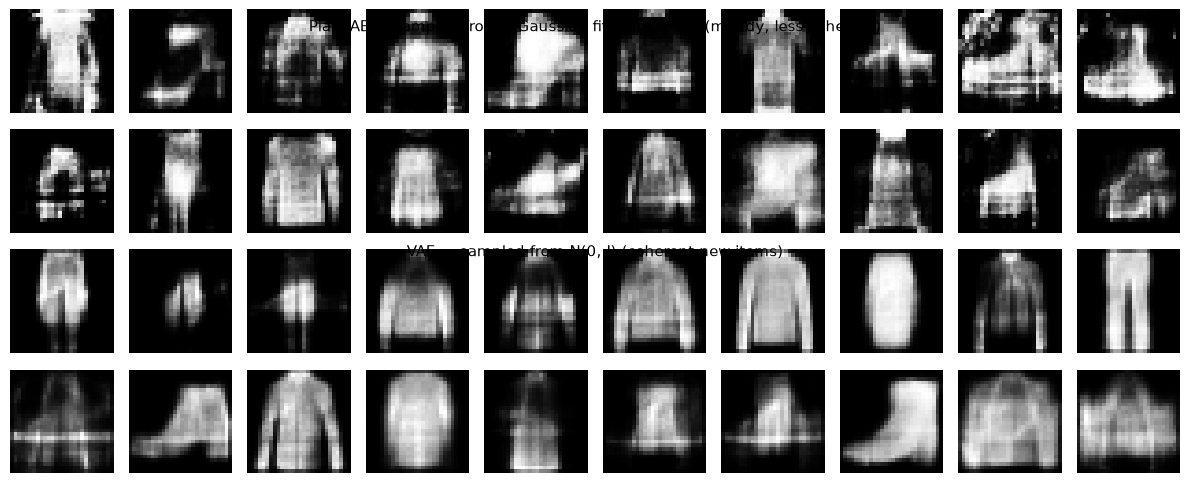

In [9]:
# Plain AE with identical shape (no KL, no sampling)
class PlainAE(nn.Module):
    def __init__(self, d=784, h=256, latent=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.ReLU(), nn.Linear(h, latent))
        self.dec = nn.Sequential(nn.Linear(latent, h), nn.ReLU(), nn.Linear(h, d), nn.Sigmoid())
    def forward(self, x): z = self.enc(x); return self.dec(z), z

torch.manual_seed(0)
pae = PlainAE(latent=16); optp = torch.optim.Adam(pae.parameters(), lr=1e-3)
for epoch in range(30):
    perm = torch.randperm(n)
    for i in range(0, n, BATCH):
        xb = X_train[perm[i:i+BATCH]]
        out, _ = pae(xb); loss = ((out - xb)**2).mean()
        optp.zero_grad(); loss.backward(); optp.step()
pae.eval()
with torch.no_grad():
    codes = pae.enc(X_train)                       # fit a Gaussian to the plain AE's codes
    cmu, cstd = codes.mean(0), codes.std(0)
    z_ae  = cmu + cstd * torch.randn(20, 16)       # sample the plain AE "as best we can"
    gen_ae  = pae.dec(z_ae)
    gen_vae = vae.decoder(torch.randn(20, 16))     # sample the VAE from N(0,I)

fig, axes = plt.subplots(4, 10, figsize=(12, 5))
for k in range(20):
    r, c = divmod(k, 10)
    axes[r, c].imshow(gen_ae[k].reshape(28,28), cmap="gray"); axes[r, c].axis("off")
    axes[r+2, c].imshow(gen_vae[k].reshape(28,28), cmap="gray"); axes[r+2, c].axis("off")
fig.text(0.5, 0.92, "Plain AE — sampled from a Gaussian fit to its codes (muddy, less coherent)", ha="center", fontsize=11)
fig.text(0.5, 0.47, "VAE — sampled from N(0, I) (coherent new items)", ha="center", fontsize=11)
plt.tight_layout(); plt.show()


## 8. Limitations & variants (know these for the interview)

- **Blurry samples.** The Gaussian decoder + KL regularization make VAE outputs **smoother/blurrier**
  than GANs or diffusion models. VAEs trade sharpness for a well-behaved, sampleable latent space and
  stable training.
- **Posterior collapse.** If the decoder is very powerful, the model can *ignore* the latent (KL → 0,
  `z` carries no information). Fixes: **KL warm-up** (ramp the KL weight up), weaker decoder, or
  **β-VAE with β<1** early.
- **β-VAE.** Scale the KL term by **β**. β>1 pressures the latent axes to become **disentangled**
  (each dimension controls one factor — e.g. sleeve length, brightness); β<1 favours reconstruction.
- **Where VAEs sit today.** For raw image *fidelity*, diffusion models won. But VAEs remain everywhere:
  as the **latent-space compressor inside latent diffusion** (e.g. Stable Diffusion encodes to a VAE
  latent first), for **anomaly detection** (low likelihood = anomaly), and wherever you need a
  **smooth, probabilistic latent** you can interpolate and reason over.


## 9. Key takeaways & interview soundbites

**The mental model**

- A VAE encodes each input to a **distribution** `N(μ, σ²)`, samples `z` via the **reparameterization
  trick**, and decodes. The **KL term** packs all codes into `N(0, I)` → a smooth, gap-free latent you
  can **sample and interpolate**. That's what turns an autoencoder into a **generative model**.
- Loss = **reconstruction + KL** (the ELBO). The two terms trade off: spread-out vs. packed-in.

**Sharp answers for an interview**

- *"Why can a VAE generate but a plain AE can't?"* → The plain AE's latent has holes and an unknown
  shape, so random codes decode to garbage. The VAE's KL term forces the codes to fill a known prior
  `N(0, I)`, so sampling and decoding always yields a valid image.
- *"What is the reparameterization trick and why do we need it?"* → Writing `z = μ + σ·ε` with
  `ε ~ N(0, I)` moves the randomness to an input, so gradients can flow through the deterministic `μ`
  and `σ`. Without it you can't backprop through the sampling step.
- *"Explain the ELBO."* → A lower bound on `log p(x)`; maximizing it = minimizing (reconstruction loss
  + KL of the approximate posterior to the prior). Reconstruction fits the data; KL regularizes the
  latent to be sampleable.
- *"Downsides / how does it compare to GANs & diffusion?"* → VAEs are stable and give a usable latent
  but produce blurrier samples; GANs are sharper but unstable; diffusion is state-of-the-art fidelity.
  VAEs are often the **latent encoder inside** modern latent-diffusion systems.
- *"What's β-VAE?"* → A VAE with a weighted KL term (β); large β encourages **disentangled** latent
  factors at some cost to reconstruction.

**Try it yourself**

1. Change `latent` (2 → 8 → 32): more dims → sharper reconstructions, harder-to-visualize latent.
2. Multiply the KL term by **β** in `vae_loss` and watch samples get smoother (β↑) or sharper (β↓).
3. Interpolate between other class pairs; sample the same `z` twice — the decoder is deterministic.
